### Environment Setup and Reproducibility
with the proper virtual environment activated (```venv``` or ```conda env```), install the following packages:

```bash
pip install torch==2.6.0 
```
and also, run ```pip check``` to make sure no broken dependencies are present.

In [1]:
# Import the necessary libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import random
import matplotlib.pyplot as plt

# Set the device to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Set the random seed for reproducibility
seed = 224040002 # any number (i.e., student ID)
torch.manual_seed(seed) # Set the random seed for PyTorch
torch.cuda.manual_seed(seed) # Set the random seed for CUDA
np.random.seed(seed) # Set the random seed for NumPy
random.seed(seed) # Set the random seed for Python
torch.backends.cudnn.deterministic = True # Set the random seed for all devices (both CPU and CUDA)

### Load and Preprocess the Datasets
load the *CIFAR-10* and MNIST datasets with necessary transformations.

In [6]:
# Define basic transformations
transform_cifar = transforms.Compose([
    transforms.ToTensor(), # Convert the image to a PyTorch tensor
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Normalize the image
])

transform_mnist = transforms.Compose([
    transforms.ToTensor(), # Convert the image to a PyTorch tensor
    transforms.Normalize((0.5,), (0.5,)) # Normalize the image
])

# Load datasets
trainset_cifar = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_cifar)
testset_cifar = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_cifar)

trainset_mnist = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform_mnist)
testset_mnist = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform_mnist)

# Create data loaders
trainloader_cifar = DataLoader(trainset_cifar, batch_size=32, shuffle=True)
testloader_cifar = DataLoader(testset_cifar, batch_size=32, shuffle=False)

trainloader_mnist = DataLoader(trainset_mnist, batch_size=32, shuffle=True)
testloader_mnist = DataLoader(testset_mnist, batch_size=32, shuffle=False)

### Experimenting with the *CIFAR-10* Dataset

#### Baseline Model with a Simple CNN

In [10]:
# Baseline model with a simple CNN
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)  # CIFAR-10 has 3 input channels
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1) # 32 input channels from the previous layer
        self.fc1 = nn.Linear(64 * 8 * 8, 256) # 64 channels, 8x8 image size
        self.fc2 = nn.Linear(256, 10) # 10 output classes
        
    def forward(self, x):
        x = F.relu(self.conv1(x)) # Apply the ReLU activation function
        x = F.max_pool2d(x, 2) # Apply max pooling with a 2x2 kernel
        x = F.relu(self.conv2(x)) # Apply the ReLU activation function
        x = F.max_pool2d(x, 2) # Apply max pooling with a 2x2 kernel
        x = torch.flatten(x, 1) # Flatten the output of the convolutional layers
        x = F.relu(self.fc1(x)) # Apply the ReLU activation function
        x = self.fc2(x) 
        return x

In [11]:
# Define the model, loss function, and optimizer
model = BaselineCNN().to(device) # Move the model to the GPU if available
criterion = nn.CrossEntropyLoss() # Define the loss function
optimizer = optim.Adam(model.parameters(), lr=0.001) # Define the optimizer

Epoch 1, Loss: 1.2444791463385465, Accuracy: 63.93%
Epoch 2, Loss: 0.8525280275752128, Accuracy: 68.21%
Epoch 3, Loss: 0.6768347883998623, Accuracy: 70.42%
Epoch 4, Loss: 0.528085991454216, Accuracy: 73.08%
Epoch 5, Loss: 0.39314831110695886, Accuracy: 73.34%
Epoch 6, Loss: 0.27119313739836026, Accuracy: 72.01%
Epoch 7, Loss: 0.19215411230950347, Accuracy: 72.16%
Epoch 8, Loss: 0.13710768365998938, Accuracy: 72.74%
Epoch 9, Loss: 0.11151094008469507, Accuracy: 71.22%
Epoch 10, Loss: 0.08991971749060693, Accuracy: 71.76%
Epoch 11, Loss: 0.0813055203503453, Accuracy: 71.4%
Epoch 12, Loss: 0.07589955149483298, Accuracy: 71.6%
Epoch 13, Loss: 0.07328816258471568, Accuracy: 71.19%
Epoch 14, Loss: 0.0626054791812499, Accuracy: 71.16%
Epoch 15, Loss: 0.06221975496214051, Accuracy: 71.0%
Epoch 16, Loss: 0.06293636578450269, Accuracy: 71.81%
Epoch 17, Loss: 0.05949361309490625, Accuracy: 70.98%
Epoch 18, Loss: 0.05588245936711585, Accuracy: 70.68%
Epoch 19, Loss: 0.04830865772509162, Accuracy: 

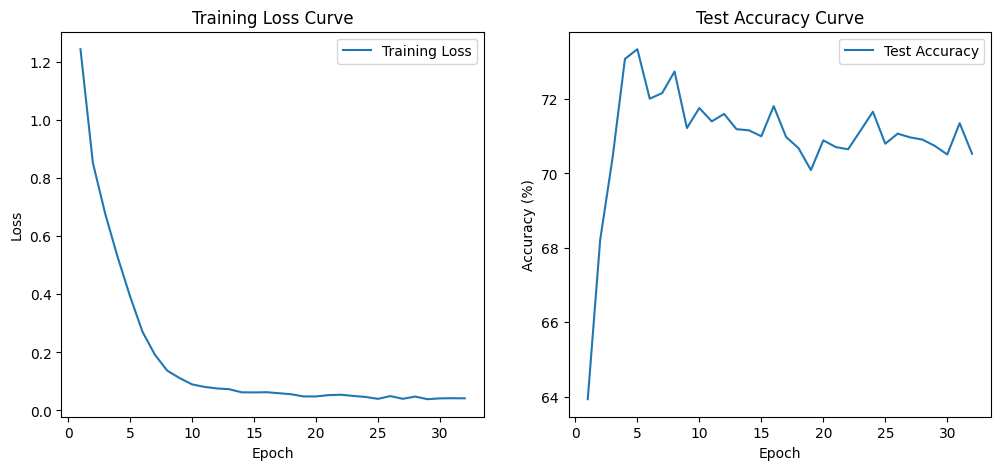

In [12]:
# Train the model
num_epochs = 32 # Define the number of epochs
losses = [] # Store the loss values
accuracies = [] # Store the test accuracies

for epoch in range(num_epochs):
    model.train() # Set the model to training mode
    running_loss = 0.0
    for i, data in enumerate(trainloader_cifar):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device) # Move the inputs and labels to the GPU if available
        optimizer.zero_grad() # Zero the parameter gradients
        outputs = model(inputs) # Forward pass
        loss = criterion(outputs, labels) # Calculate the loss
        backward() # Backward pass
        optimizer.step() # Optimize
        running_loss += loss.item() # Add the loss

    losses.append(running_loss / len(trainloader_cifar)) # Calculate the average loss

    # Evaluate the model
    model.eval() # Set the model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():
        for data in testloader_cifar:
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device) # Move the inputs and labels to the GPU if available
            outputs = model(inputs) # Forward pass
            _, predicted = torch.max(outputs.data, 1) # Get the predicted class
            total += labels.size(0) # Update the total count
            correct += (predicted == labels).sum().item() # Update the correct count

    accuracies.append(100 * correct / total) # Calculate the test accuracy
    print(f'Epoch {epoch + 1}, Loss: {running_loss / len(trainloader_cifar)}, Accuracy: {100 * correct / total}%')

# Visualize the training process
# Plot the training loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1,  len(losses)+ 1), losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()

# Plot the test accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, len(losses) + 1), accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Test Accuracy Curve')
plt.legend()

plt.show()

#### Improved Model with Batch Normalization

In [31]:
# Improved model with batch normalization
class ImprovedCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1) # 3 input channels, 32 output channels
        self.bn1 = nn.BatchNorm2d(32) # Batch normalization stabilizes the learning process
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1) # 32 input channels, 64 output channels
        self.bn2 = nn.BatchNorm2d(64) # Batch normalization stabilizes the learning
        self.fc1 = nn.Linear(64 * 8 * 8, 256) # 64 channels, 8x8 image size
        self.fc2 = nn.Linear(256, 10) # 10 output classes
        
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x))) # Apply batch normalization before activation / after convolution
        x = F.max_pool2d(x, 2) # Apply max pooling with a 2x2 kernel
        x = F.relu(self.bn2(self.conv2(x))) # Apply batch normalization before activation / after convolution
        x = F.max_pool2d(x, 2) # Apply max pooling with a 2x2 kernel
        x = torch.flatten(x, 1) # Flatten the output of the convolutional layers
        x = F.relu(self.fc1(x)) # Apply the ReLU activation function
        x = self.fc2(x) 
        return x

In [32]:
# Define the model, loss function, and optimizer
model = ImprovedCNN().to(device) # Move the model to the GPU if available
criterion = nn.CrossEntropyLoss() # Define the loss function
optimizer = optim.Adam(model.parameters(), lr=0.001) # Define the optimizer

Epoch 1, Loss: 1.2418147312931274, Accuracy: 62.01%
Epoch 2, Loss: 0.9170850020948313, Accuracy: 67.88%
Epoch 3, Loss: 0.7810425062211599, Accuracy: 71.24%
Epoch 4, Loss: 0.6849700469220974, Accuracy: 71.51%
Epoch 5, Loss: 0.5927403355380776, Accuracy: 72.79%
Epoch 6, Loss: 0.5171498464645671, Accuracy: 73.71%
Epoch 7, Loss: 0.447992349144784, Accuracy: 72.88%
Epoch 8, Loss: 0.38673731248041643, Accuracy: 72.42%
Epoch 9, Loss: 0.3283020224820248, Accuracy: 73.54%
Epoch 10, Loss: 0.27885708985677415, Accuracy: 72.64%
Epoch 11, Loss: 0.23370204071537548, Accuracy: 72.89%
Epoch 12, Loss: 0.20367276999010195, Accuracy: 73.22%
Epoch 13, Loss: 0.17392345883907967, Accuracy: 73.87%
Epoch 14, Loss: 0.15534255233869165, Accuracy: 73.02%
Epoch 15, Loss: 0.13713185864745597, Accuracy: 72.25%
Epoch 16, Loss: 0.11955327756186888, Accuracy: 72.41%


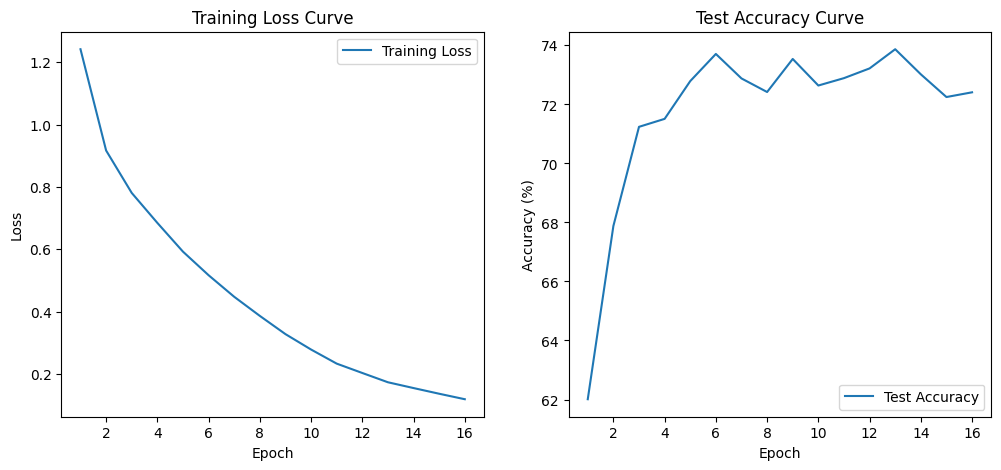

In [33]:
# Train the model
num_epochs = 32 # Define the number of epochs
losses = [] # Store the loss values
accuracies = [] # Store the test accuracies

for epoch in range(num_epochs):
    model.train() # Set the model to training mode
    running_loss = 0.0
    for i, data in enumerate(trainloader_cifar):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device) # Move the inputs and labels to the GPU if available
        optimizer.zero_grad() # Zero the parameter gradients
        outputs = model(inputs) # Forward pass
        loss = criterion(outputs, labels) # Calculate the loss
        backward() # Backward pass
        optimizer.step() # Optimize
        running_loss += loss.item() # Add the loss

    losses.append(running_loss / len(trainloader_cifar)) # Calculate the average loss

    # Evaluate the model
    model.eval() # Set the model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():
        for data in testloader_cifar:
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device) # Move the inputs and labels to the GPU if available
            outputs = model(inputs) # Forward pass
            _, predicted = torch.max(outputs.data, 1) # Get the predicted class
            total += labels.size(0) # Update the total count
            correct += (predicted == labels).sum().item() # Update the correct count
            
    accuracies.append(100 * correct / total) # Calculate the test accuracy
    print(f'Epoch {epoch + 1}, Loss: {running_loss / len(trainloader_cifar)}, Accuracy: {100 * correct / total}%')
    
# Visualize the training process
# Plot the training loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1,  len(losses)+ 1), losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()

# Plot the test accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, len(losses) + 1), accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Test Accuracy Curve')
plt.legend()

plt.show()

#### Updated CIFAR-10 Transform with Augmentation

In [4]:
# Updated CIFAR-10 transform with augmentation
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(), # Randomly flip the image horizontally to reduce overfitting
    transforms.RandomRotation(10), # Randomly rotate the image by 10 degrees
    transforms.RandomAffine(0, shear=10, scale=(0.8, 1.2)), # Random affine transformation
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # Randomly change the brightness, contrast, and saturation
    transforms.ToTensor(), # Convert the image to a PyTorch tensor
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Normalize the image
])

In [5]:
# Load the CIFAR-10 dataset with the updated transform
trainset_cifar = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader_cifar = DataLoader(trainset_cifar, batch_size=64, shuffle=True, num_workers=2)

Epoch 1, Loss: 1.4482985943155418, Accuracy: 58.68%
Epoch 2, Loss: 1.1615776714421355, Accuracy: 64.19%
Epoch 3, Loss: 1.0518460482339864, Accuracy: 67.74%
Epoch 4, Loss: 0.982121868844377, Accuracy: 70.03%
Epoch 5, Loss: 0.9364505621651694, Accuracy: 70.93%
Epoch 6, Loss: 0.8913954592101938, Accuracy: 72.17%
Epoch 7, Loss: 0.859562647415138, Accuracy: 73.5%
Epoch 8, Loss: 0.8346006935098884, Accuracy: 73.75%
Epoch 9, Loss: 0.8073220708129197, Accuracy: 74.16%
Epoch 10, Loss: 0.7846116355726983, Accuracy: 75.87%
Epoch 11, Loss: 0.7670661222644899, Accuracy: 74.68%
Epoch 12, Loss: 0.7509800566173256, Accuracy: 76.54%
Epoch 13, Loss: 0.7340340256424036, Accuracy: 75.9%
Epoch 14, Loss: 0.720934794335051, Accuracy: 76.32%
Epoch 15, Loss: 0.7128719186561655, Accuracy: 76.2%
Epoch 16, Loss: 0.6988863232268482, Accuracy: 76.45%
Epoch 17, Loss: 0.6907173766494179, Accuracy: 76.39%
Epoch 18, Loss: 0.68182050140714, Accuracy: 76.84%
Epoch 19, Loss: 0.6699526697320962, Accuracy: 77.2%
Epoch 20, L

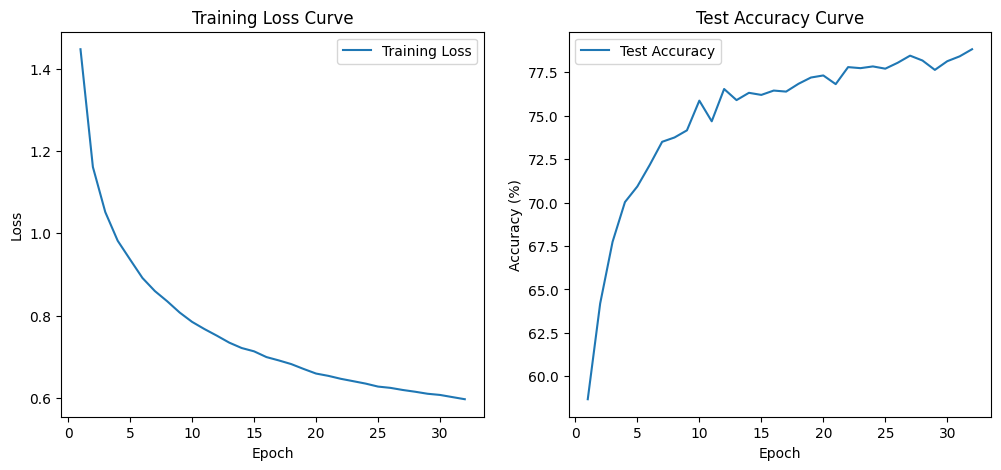

In [40]:
# Train the model with the updated transform
model = ImprovedCNN().to(device) # Move the model to the GPU if available
criterion = nn.CrossEntropyLoss() # Define the loss function
optimizer = optim.Adam(model.parameters(), lr=0.001) # Define the optimizer

num_epochs = 32 # Define the number of epochs
losses = [] # Store the loss values
accuracies = [] # Store the test accuracies

for epoch in range(num_epochs):
    model.train() # Set the model to training mode
    running_loss = 0.0
    for i, data in enumerate(trainloader_cifar):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device) # Move the inputs and labels to the GPU if available
        optimizer.zero_grad() # Zero the parameter gradients
        outputs = model(inputs) # Forward pass
        loss = criterion(outputs, labels) # Calculate the loss
        backward() # Backward pass
        optimizer.step() # Optimize
        running_loss += loss.item() # Add the loss

    losses.append(running_loss / len(trainloader_cifar)) # Calculate the average loss

    # Evaluate the model
    model.eval() # Set the model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():
        for data in testloader_cifar:
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device) # Move the inputs and labels to the GPU if available
            outputs = model(inputs) # Forward pass
            _, predicted = torch.max(outputs.data, 1) # Get the predicted class
            total += labels.size(0) # Update the total count
            correct += (predicted == labels).sum().item() # Update the correct count
            
    accuracies.append(100 * correct / total) # Calculate the test accuracy
    print(f'Epoch {epoch + 1}, Loss: {running_loss / len(trainloader_cifar)}, Accuracy: {100 * correct / total}%')
    
# Visualize the training process
# Plot the training loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1,  len(losses)+ 1), losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()

# Plot the test accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, len(losses) + 1), accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Test Accuracy Curve')
plt.legend()

plt.show()

#### Deeper Neural Network with Dropout

In [37]:
# Deeper neural network with dropout
class DeeperCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1) # 3 input channels, 32 output channels
        self.bn1 = nn.BatchNorm2d(32) # Batch normalization stabilizes the learning process
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1) # 32 input channels, 64 output channels
        self.bn2 = nn.BatchNorm2d(64) # Batch normalization stabilizes the learning
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1) # 64 input channels, 128 output channels
        self.bn3 = nn.BatchNorm2d(128) # Batch normalization stabilizes the learning
        self.fc1 = nn.Linear(128 * 4 * 4, 512) # 128 channels, 4x4 image size
        self.fc2 = nn.Linear(512, 10) # 10 output classes
        self.dropout = nn.Dropout(0.2) # Apply dropout with a probability of 0.2
        
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x))) # Apply batch normalization before activation / after convolution
        x = F.max_pool2d(x, 2) # Apply max pooling with a 2x2 kernel
        x = F.relu(self.bn2(self.conv2(x))) # Apply batch normalization before activation / after convolution
        x = F.max_pool2d(x, 2) # Apply max pooling with a 2x2 kernel
        x = F.relu(self.bn3(self.conv3(x))) # Apply batch normalization before activation / after convolution
        x = F.max_pool2d(x, 2) # Apply max pooling with a 2x2 kernel
        x = torch.flatten(x, 1) # Flatten the output of the convolutional layers
        x = F.relu(self.fc1(x)) # Apply the ReLU activation function
        x = self.dropout(x) # Apply dropout
        x = self.fc2(x) 
        return x

In [38]:
# Define the model, loss function, and optimizer
model = DeeperCNN().to(device) # Move the model to the GPU if available
criterion = nn.CrossEntropyLoss() # Define the loss function
optimizer = optim.Adam(model.parameters(), lr=0.001) # Define the optimizer

Epoch 1, Loss: 1.449941553866642, Accuracy: 62.22%
Epoch 2, Loss: 1.1186452730298424, Accuracy: 66.03%
Epoch 3, Loss: 0.9901432476208444, Accuracy: 69.71%
Epoch 4, Loss: 0.9100836366701035, Accuracy: 73.85%
Epoch 5, Loss: 0.8494529586454576, Accuracy: 75.42%
Epoch 6, Loss: 0.8074997153254708, Accuracy: 76.31%
Epoch 7, Loss: 0.7782179166968634, Accuracy: 78.09%
Epoch 8, Loss: 0.747503871671374, Accuracy: 78.37%
Epoch 9, Loss: 0.7239951598514598, Accuracy: 79.4%
Epoch 10, Loss: 0.6999759281474813, Accuracy: 79.46%
Epoch 11, Loss: 0.6796160475496901, Accuracy: 79.97%
Epoch 12, Loss: 0.6703900915647423, Accuracy: 78.96%
Epoch 13, Loss: 0.6576888396697249, Accuracy: 79.34%
Epoch 14, Loss: 0.6397416167871661, Accuracy: 80.61%
Epoch 15, Loss: 0.6268085655842693, Accuracy: 81.4%
Epoch 16, Loss: 0.6156481479366697, Accuracy: 81.23%
Epoch 17, Loss: 0.6055893476049029, Accuracy: 81.33%
Epoch 18, Loss: 0.5968568782659959, Accuracy: 81.82%
Epoch 19, Loss: 0.5794858688289587, Accuracy: 80.79%
Epoch 

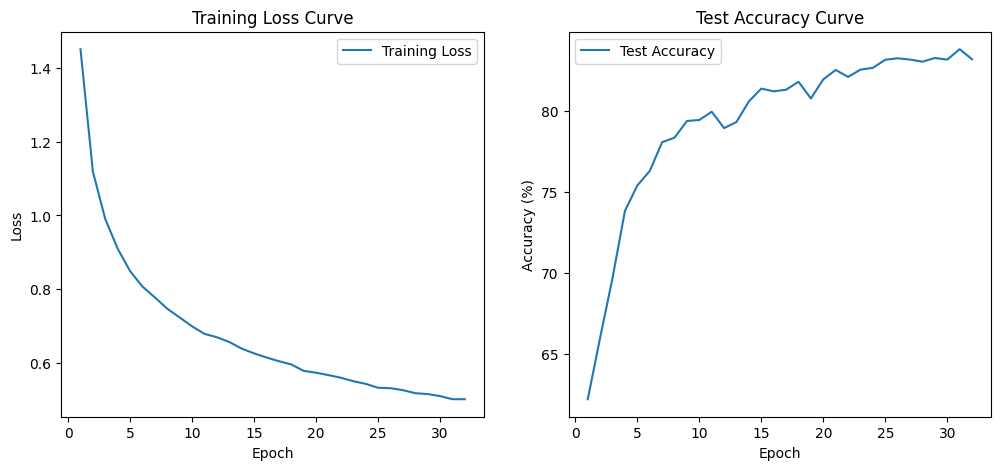

In [39]:
# Train the model
num_epochs = 32 # Define the number of epochs
losses = [] # Store the loss values
accuracies = [] # Store the test accuracies

for epoch in range(num_epochs):
    model.train() # Set the model to training mode
    running_loss = 0.0
    for i, data in enumerate(trainloader_cifar):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device) # Move the inputs and labels to the GPU if available
        optimizer.zero_grad() # Zero the parameter gradients
        outputs = model(inputs) # Forward pass
        loss = criterion(outputs, labels) # Calculate the loss
        backward() # Backward pass
        optimizer.step() # Optimize
        running_loss += loss.item() # Add the loss

    losses.append(running_loss / len(trainloader_cifar)) # Calculate the average loss

    # Evaluate the model
    model.eval() # Set the model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():
        for data in testloader_cifar:
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device) # Move the inputs and labels to the GPU if available
            outputs = model(inputs) # Forward pass
            _, predicted = torch.max(outputs.data, 1) # Get the predicted class
            total += labels.size(0) # Update the total count
            correct += (predicted == labels).sum().item() # Update the correct count
            
    accuracies.append(100 * correct / total) # Calculate the test accuracy
    print(f'Epoch {epoch + 1}, Loss: {running_loss / len(trainloader_cifar)}, Accuracy: {100 * correct / total}%')
    
# Visualize the training process
# Plot the training loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1,  len(losses)+ 1), losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()

# Plot the test accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, len(losses) + 1), accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Test Accuracy Curve')
plt.legend()

plt.show()

#### Baseline from Example-Code

In [3]:
# Define the baseline model from the example code
ExampleBaselineCNN = nn.Sequential(
    nn.Conv2d(3, 128, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2), nn.Dropout(0.3),
    nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2), nn.Dropout(0.3),
    nn.Conv2d(256, 512, 3, padding=1), nn.ReLU(inplace=True),
    nn.Conv2d(512, 512, 3, padding=1), nn.ReLU(inplace=True),
    nn.Conv2d(512, 256, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2), nn.Dropout(0.3),
    nn.Flatten(),
    nn.Linear(256 * 4 * 4, 512), nn.ReLU(inplace=True), nn.Dropout(0.5),
    nn.Linear(512, 256), nn.ReLU(inplace=True), nn.Dropout(0.5),
    nn.Linear(256, 128), nn.ReLU(inplace=True), nn.Dropout(0.5),
    nn.Linear(128, 10),
)

In [6]:
model = ExampleBaselineCNN.to(device) # Move the model to the GPU if available
criterion = nn.CrossEntropyLoss() # Define the loss function
optimizer = optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-6) # Define the optimizer

Epoch 1, Loss: 1.986582514727512, Accuracy: 38.05%
Epoch 2, Loss: 1.6358834506605593, Accuracy: 50.98%
Epoch 3, Loss: 1.4313442717732676, Accuracy: 54.39%
Epoch 4, Loss: 1.303736082656914, Accuracy: 62.64%
Epoch 5, Loss: 1.2063032602867507, Accuracy: 63.77%
Epoch 6, Loss: 1.1290180972774926, Accuracy: 68.18%
Epoch 7, Loss: 1.0574383551964674, Accuracy: 71.39%
Epoch 8, Loss: 1.0128745659233054, Accuracy: 71.56%
Epoch 9, Loss: 0.9634831495906996, Accuracy: 74.48%
Epoch 10, Loss: 0.9211004398515462, Accuracy: 74.81%
Epoch 11, Loss: 0.8817519272684746, Accuracy: 75.82%
Epoch 12, Loss: 0.8544820382085907, Accuracy: 77.09%
Epoch 13, Loss: 0.8245397912495581, Accuracy: 77.83%
Epoch 14, Loss: 0.7987971341289828, Accuracy: 78.39%
Epoch 15, Loss: 0.7705363750915089, Accuracy: 79.04%
Epoch 16, Loss: 0.7516486368063465, Accuracy: 79.53%
Epoch 17, Loss: 0.7318746229190656, Accuracy: 80.47%
Epoch 18, Loss: 0.7153137419229884, Accuracy: 81.04%
Epoch 19, Loss: 0.7012961281230078, Accuracy: 81.08%
Epoc

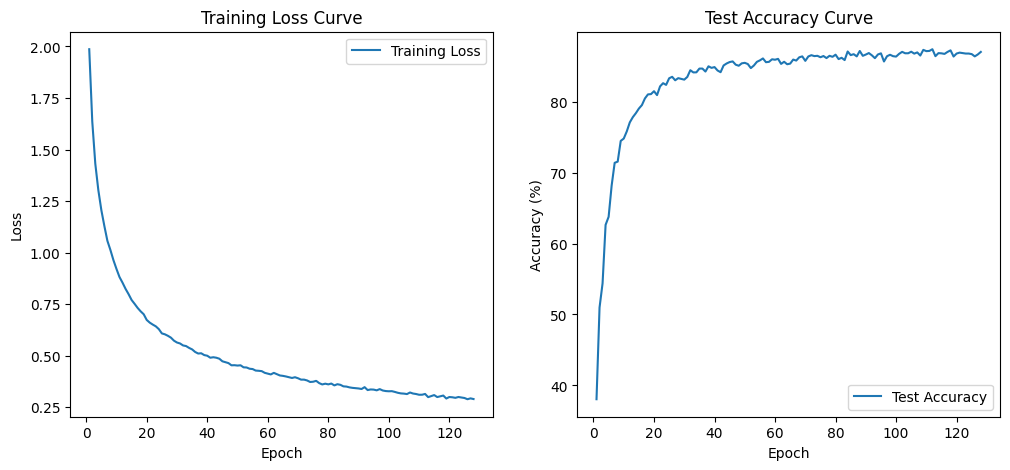

In [7]:
# Train the model
num_epochs = 128 # Define the number of epochs
losses = [] # Store the loss values
accuracies = [] # Store the test accuracies

for epoch in range(num_epochs):
    model.train() # Set the model to training mode
    running_loss = 0.0
    for i, data in enumerate(trainloader_cifar):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device) # Move the inputs and labels to the GPU if available
        optimizer.zero_grad() # Zero the parameter gradients
        outputs = model(inputs) # Forward pass
        loss = criterion(outputs, labels) # Calculate the loss
        backward() # Backward pass
        optimizer.step() # Optimize
        running_loss += loss.item() # Add the loss

    losses.append(running_loss / len(trainloader_cifar)) # Calculate the average loss

    # Evaluate the model
    model.eval() # Set the model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():
        for data in testloader_cifar:
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device) # Move the inputs and labels to the GPU if available
            outputs = model(inputs) # Forward pass
            _, predicted = torch.max(outputs.data, 1) # Get the predicted class
            total += labels.size(0) # Update the total count
            correct += (predicted == labels).sum().item() # Update the correct count
            
    accuracies.append(100 * correct / total) # Calculate the test accuracy
    print(f'Epoch {epoch + 1}, Loss: {running_loss / len(trainloader_cifar)}, Accuracy: {100 * correct / total}%')
    
# Visualize the training process
# Plot the training loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1,  len(losses)+ 1), losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()

# Plot the test accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, len(losses) + 1), accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Test Accuracy Curve')
plt.legend()

plt.show()

#### Enhanced Example Baseline Model

In [8]:
OptimizedCNN = nn.Sequential(
    nn.Conv2d(3, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2, 2), nn.Dropout(0.3),
    nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True), nn.MaxPool2d(2, 2), nn.Dropout(0.3),
    nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
    nn.Conv2d(512, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
    nn.Conv2d(512, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True), nn.MaxPool2d(2, 2), nn.Dropout(0.3),
    nn.Flatten(),
    nn.Linear(256 * 4 * 4, 512), nn.ReLU(inplace=True), nn.Dropout(0.5),
    nn.Linear(512, 256), nn.ReLU(inplace=True), nn.Dropout(0.5),
    nn.Linear(256, 128), nn.ReLU(inplace=True), nn.Dropout(0.5),
    nn.Linear(128, 10)
)

In [9]:
model = OptimizedCNN.to(device) # Move the model to the GPU if available
criterion = nn.CrossEntropyLoss() # Define the loss function
optimizer = optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-6) # Define the optimizer

Epoch 1, Loss: 1.8244729110651918, Accuracy: 47.21%
Epoch 2, Loss: 1.4721431274853094, Accuracy: 58.53%
Epoch 3, Loss: 1.2977739638837098, Accuracy: 63.65%
Epoch 4, Loss: 1.1819100036950367, Accuracy: 68.44%
Epoch 5, Loss: 1.1020960810849123, Accuracy: 71.03%
Epoch 6, Loss: 1.0392186951149456, Accuracy: 71.72%
Epoch 7, Loss: 0.9928377732596434, Accuracy: 73.27%
Epoch 8, Loss: 0.9470800723871002, Accuracy: 75.24%
Epoch 9, Loss: 0.9082043263156091, Accuracy: 77.26%
Epoch 10, Loss: 0.8795024949647582, Accuracy: 75.89%
Epoch 11, Loss: 0.8484757025452221, Accuracy: 79.07%
Epoch 12, Loss: 0.8288102354997259, Accuracy: 77.86%
Epoch 13, Loss: 0.7966212179426038, Accuracy: 78.28%
Epoch 14, Loss: 0.771217441276821, Accuracy: 80.86%
Epoch 15, Loss: 0.760543236189791, Accuracy: 80.94%
Epoch 16, Loss: 0.7368364117639449, Accuracy: 81.08%
Epoch 17, Loss: 0.7212076333477674, Accuracy: 82.52%
Epoch 18, Loss: 0.693262556096172, Accuracy: 81.91%
Epoch 19, Loss: 0.6750392199248609, Accuracy: 82.48%
Epoch

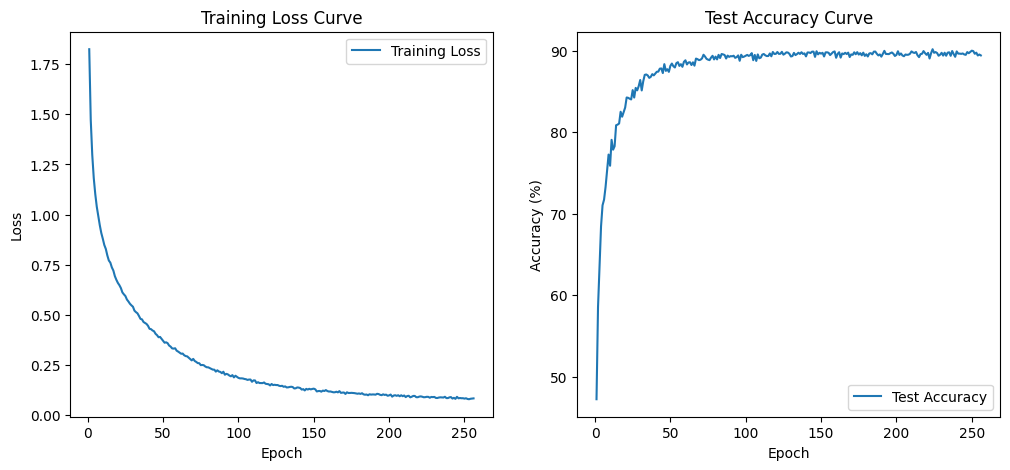

In [10]:
# Train the model
num_epochs = 256 # Define the number of epochs
losses = [] # Store the loss values
accuracies = [] # Store the test accuracies

for epoch in range(num_epochs):
    model.train() # Set the model to training mode
    running_loss = 0.0
    for i, data in enumerate(trainloader_cifar):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device) # Move the inputs and labels to the GPU if available
        optimizer.zero_grad() # Zero the parameter gradients
        outputs = model(inputs) # Forward pass
        loss = criterion(outputs, labels) # Calculate the loss
        backward() # Backward pass
        optimizer.step() # Optimize
        running_loss += loss.item() # Add the loss

    losses.append(running_loss / len(trainloader_cifar)) # Calculate the average loss

    # Evaluate the model
    model.eval() # Set the model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():
        for data in testloader_cifar:
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device) # Move the inputs and labels to the GPU if available
            outputs = model(inputs) # Forward pass
            _, predicted = torch.max(outputs.data, 1) # Get the predicted class
            total += labels.size(0) # Update the total count
            correct += (predicted == labels).sum().item() # Update the correct count
            
    accuracies.append(100 * correct / total) # Calculate the test accuracy
    print(f'Epoch {epoch + 1}, Loss: {running_loss / len(trainloader_cifar)}, Accuracy: {100 * correct / total}%')
    
# Visualize the training process
# Plot the training loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1,  len(losses)+ 1), losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()

# Plot the test accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, len(losses) + 1), accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Test Accuracy Curve')
plt.legend()

plt.show()

### Apply the Best Model to the MNIST Dataset

#### Modify input channels and output classes for MNIST

In [2]:
# Define the model for the MNIST dataset
class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1) # MNIST has 1 input channel
        self.bn1 = nn.BatchNorm2d(32) # Batch normalization stabilizes the learning process
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1) # 32 input channels, 64 output channels
        self.bn2 = nn.BatchNorm2d(64) # Batch normalization stabilizes the learning
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1) # 64 input channels, 128 output channels
        self.bn3 = nn.BatchNorm2d(128) # Batch normalization stabilizes the learning
        self.fc1 = nn.Linear(128 * 3 * 3, 512) # Adjusted input size for the fully connected layer
        self.fc2 = nn.Linear(512, 10) # 10 output classes
        self.dropout = nn.Dropout(0.2) # Apply dropout with a probability of 0.2

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x))) # Apply batch normalization before activation / after convolution
        x = F.max_pool2d(x, 2) # Apply max pooling with a 2x2 kernel
        x = F.relu(self.bn2(self.conv2(x))) # Apply batch normalization before activation / after convolution
        x = F.max_pool2d(x, 2) # Apply max pooling with a 2x2 kernel
        x = F.relu(self.bn3(self.conv3(x))) # Apply batch normalization before activation / after convolution
        x = F.max_pool2d(x, 2) # Apply max pooling with a 2x2 kernel
        x = torch.flatten(x, 1) # Flatten the output of the convolutional layers
        x = F.relu(self.fc1(x)) # Apply the ReLU activation function
        x = self.dropout(x) # Apply dropout
        x = self.fc2(x)
        return x

In [3]:
# Modify the MNIST transform with augmentation
transform_mnist = transforms.Compose([
    transforms.RandomHorizontalFlip(), # Randomly flip the image horizontally to reduce overfitting
    transforms.RandomRotation(10), # Randomly rotate the image by 10 degrees
    transforms.RandomAffine(0, shear=10, scale=(0.8, 1.2)), # Random affine transformation
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # Randomly change the brightness, contrast, and saturation
    transforms.ToTensor(), # Convert the image to a PyTorch tensor
    transforms.Normalize((0.5,), (0.5,)) # Normalize the image for a single channel
])

# Load the MNIST dataset with the updated transform
trainset_mnist = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform_mnist)
testset_mnist = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform_mnist)

trainloader_mnist = DataLoader(trainset_mnist, batch_size=32, shuffle=True)
testloader_mnist = DataLoader(testset_mnist, batch_size=32, shuffle=False)

In [4]:
# Define the model, loss function, and optimizer
model = MNIST_CNN().to(device) # Move the model to the GPU if available
criterion = nn.CrossEntropyLoss() # Define the loss function
optimizer = optim.Adam(model.parameters(), lr=0.001) # Define the optimizer

Epoch 1, Loss: 0.24868558031395077, Accuracy: 94.1%
Epoch 2, Loss: 0.11581246924636264, Accuracy: 97.39%
Epoch 3, Loss: 0.09476599234330157, Accuracy: 97.57%
Epoch 4, Loss: 0.0835887378620915, Accuracy: 97.85%
Epoch 5, Loss: 0.07212253875749496, Accuracy: 98.31%
Epoch 6, Loss: 0.0656903862706696, Accuracy: 97.89%
Epoch 7, Loss: 0.06324159170377534, Accuracy: 98.48%
Epoch 8, Loss: 0.05986162139514927, Accuracy: 98.51%
Epoch 9, Loss: 0.054907077771580465, Accuracy: 97.87%
Epoch 10, Loss: 0.05253242195485703, Accuracy: 98.32%
Epoch 11, Loss: 0.05242875262244294, Accuracy: 98.66%
Epoch 12, Loss: 0.04933685590587556, Accuracy: 98.44%
Epoch 13, Loss: 0.04740198493632488, Accuracy: 98.51%
Epoch 14, Loss: 0.04688360459257092, Accuracy: 98.37%
Epoch 15, Loss: 0.04575875164159807, Accuracy: 98.61%
Epoch 16, Loss: 0.0436335244274931, Accuracy: 98.53%
Epoch 17, Loss: 0.04221900259564185, Accuracy: 98.5%
Epoch 18, Loss: 0.039945032987481685, Accuracy: 98.65%
Epoch 19, Loss: 0.04099572008047835, Acc

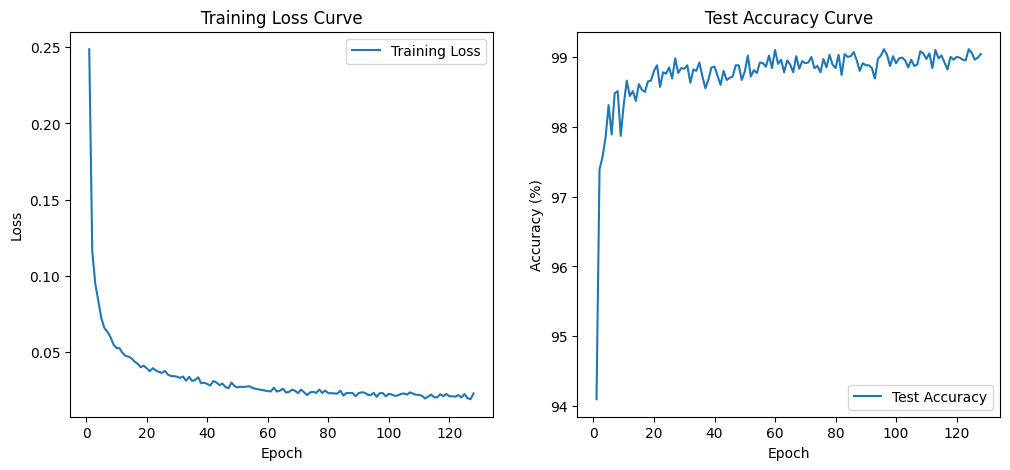

In [5]:
# Train the model
num_epochs = 128 # Define the number of epochs
losses = [] # Store the loss values
accuracies = [] # Store the test accuracies

for epoch in range(num_epochs):
    model.train() # Set the model to training mode
    running_loss = 0.0
    for i, data in enumerate(trainloader_mnist):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device) # Move the inputs and labels to the GPU if available
        optimizer.zero_grad() # Zero the parameter gradients
        outputs = model(inputs) # Forward pass
        loss = criterion(outputs, labels) # Calculate the loss
        backward() # Backward pass
        optimizer.step() # Optimize
        running_loss += loss.item() # Add the loss

    losses.append(running_loss / len(trainloader_mnist)) # Calculate the average loss

    # Evaluate the model
    model.eval() # Set the model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():
        for data in testloader_mnist:
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device) # Move the inputs and labels to the GPU if available
            outputs = model(inputs) # Forward pass
            _, predicted = torch.max(outputs.data, 1) # Get the predicted class
            total += labels.size(0) # Update the total count
            correct += (predicted == labels).sum().item() # Update the correct count
            
    accuracies.append(100 * correct / total) # Calculate the test accuracy
    print(f'Epoch {epoch + 1}, Loss: {running_loss / len(trainloader_mnist)}, Accuracy: {100 * correct / total}%')
    
# Visualize the training process
# Plot the training loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1,  len(losses)+ 1), losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()

# Plot the test accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, len(losses) + 1), accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Test Accuracy Curve')
plt.legend()

plt.show()


###  Examine and Compare Input Samples for the CIFAR-10 and MNIST Datasets

In [6]:
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
import numpy as np

# Baseline transformations
transform_baseline_cifar = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_baseline_mnist = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Augmented transformations
transform_augmented_cifar = transforms.Compose([
    transforms.RandomHorizontalFlip(), # Randomly flip the image horizontally to reduce overfitting
    transforms.RandomRotation(10), # Randomly rotate the image by 10 degrees
    transforms.RandomAffine(0, shear=10, scale=(0.8, 1.2)), # Random affine transformation
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # Randomly change the brightness, contrast, and saturation
    transforms.ToTensor(), # Convert the image to a PyTorch tensor
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Normalize the image
])

transform_augmented_mnist = transforms.Compose([
    transforms.RandomHorizontalFlip(), # Randomly flip the image horizontally to reduce overfitting
    transforms.RandomRotation(10), # Randomly rotate the image by 10 degrees
    transforms.RandomAffine(0, shear=10, scale=(0.8, 1.2)), # Random affine transformation
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # Randomly change the brightness, contrast, and saturation
    transforms.ToTensor(), # Convert the image to a PyTorch tensor
    transforms.Normalize((0.5,), (0.5,)) # Normalize the image for a single channel
])

# Load datasets
cifar_baseline = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_baseline_cifar)
cifar_augmented = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_augmented_cifar)

mnist_baseline = datasets.MNIST(root='./data', train=True, download=True, transform=transform_baseline_mnist)
mnist_augmented = datasets.MNIST(root='./data', train=True, download=True, transform=transform_augmented_mnist)

In [7]:
def show_images_side_by_side(dataset1, dataset2, title1, title2, num_samples=5):
    # Create a figure with two subplots
    fig, axes = plt.subplots(2, num_samples, figsize=(15, 6))
    fig.suptitle("CIFAR-10 Baseline vs Augmented Samples", fontsize=16)
    
    # Plot baseline samples
    for i in range(num_samples):
        img, label = dataset1[i]
        img = img.numpy().transpose((1, 2, 0))  # Convert from CxHxW to HxWxC
        img = np.clip(img, 0, 1)  # Clip values to [0, 1] for visualization
        axes[0, i].imshow(img)
        axes[0, i].axis('off')
    axes[0, 0].set_ylabel(title1, fontsize=12)

    # Plot augmented samples
    for i in range(num_samples):
        img, label = dataset2[i]
        img = img.numpy().transpose((1, 2, 0))  # Convert from CxHxW to HxWxC
        img = np.clip(img, 0, 1)  # Clip values to [0, 1] for visualization
        axes[1, i].imshow(img)
        axes[1, i].axis('off')
    axes[1, 0].set_ylabel(title2, fontsize=12)

    plt.tight_layout()
    plt.show()

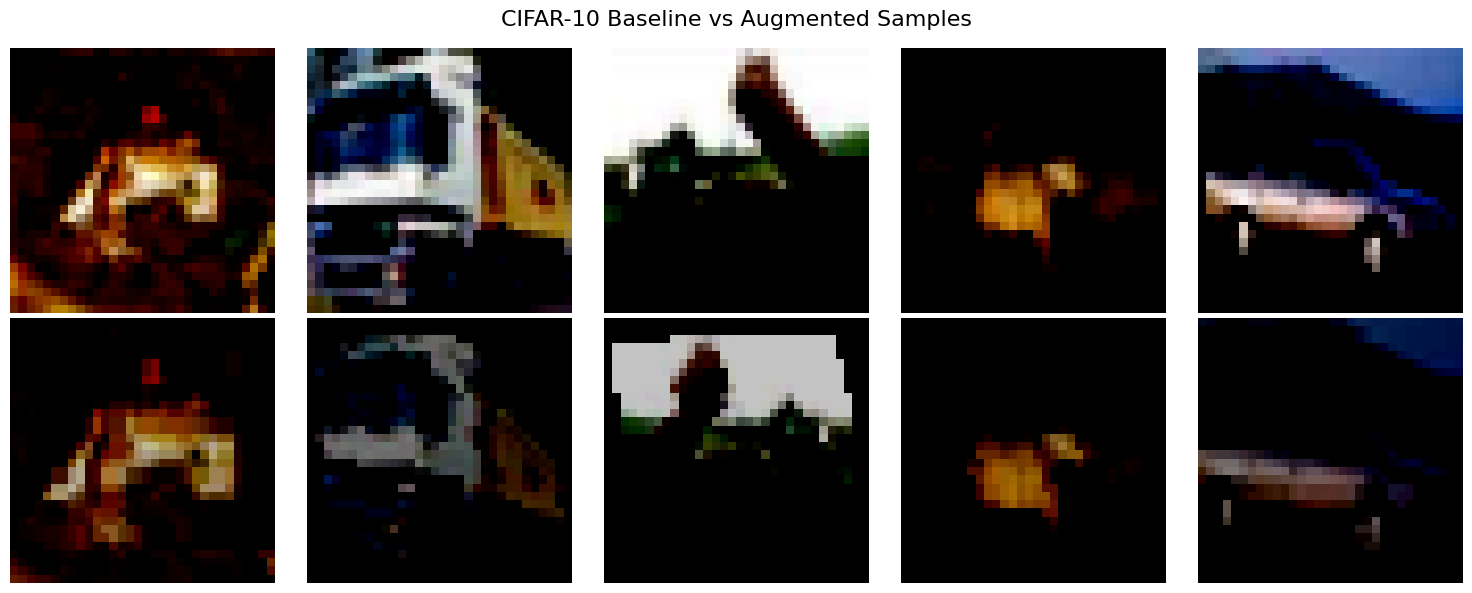

In [8]:
# Display baseline and augmented samples side by side
show_images_side_by_side(cifar_baseline, cifar_augmented, "CIFAR-10 Baseline Samples", "CIFAR-10 Augmented Samples")

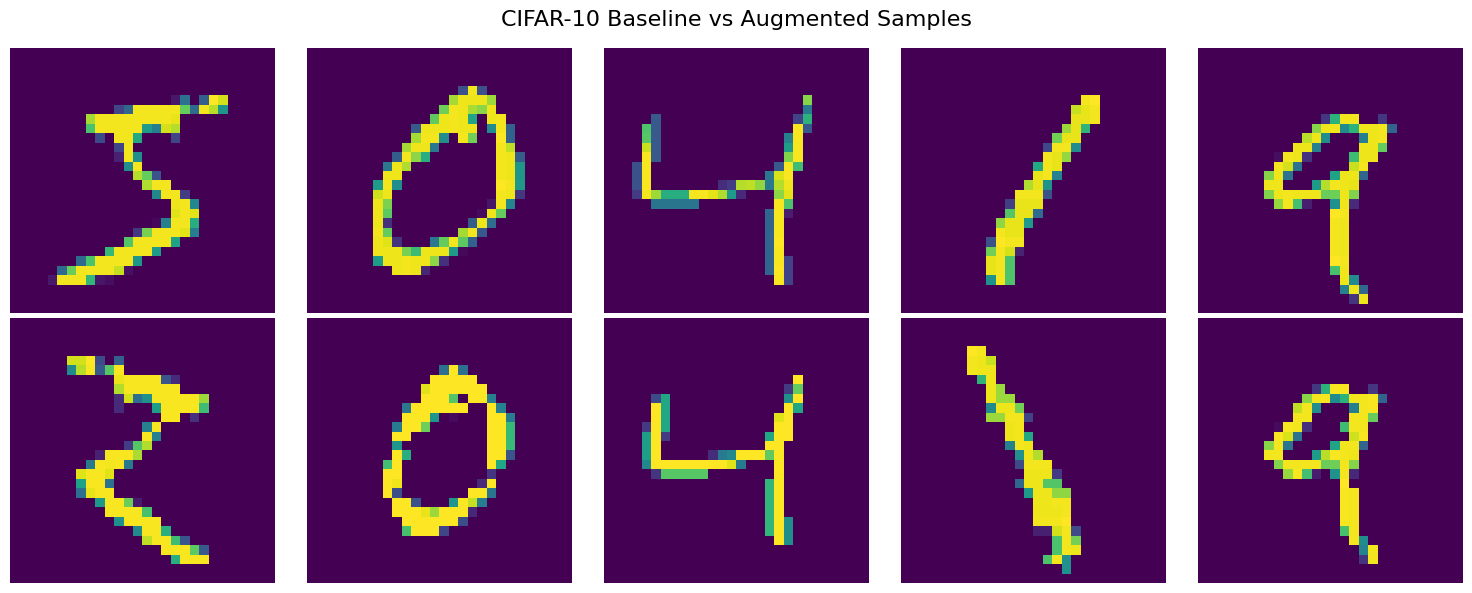

In [9]:
# Display baseline and augmented samples side by side
show_images_side_by_side(mnist_baseline, mnist_augmented, "MNIST Baseline Samples", "MNIST Augmented Samples")